In [1]:
import os
import numpy as np
import cv2
from paddleocr import PaddleOCR 
import matplotlib.pyplot as plt
import time

/home/vhvhs/MirrorMyManga/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import paddle
paddle.

AttributeError: module 'paddle' has no attribute 'device'

In [ ]:
reader = PaddleOCR(lang='en', enable_mkldnn=False, use_doc_orientation_classify=False, use_doc_unwarping=False, use_textline_orientation=False, device="gpu")

panel = cv2.imread('/home/vhvhs/MirrorMyManga/testFolder4/testImage.png')
panel = np.asarray(panel)

detection = reader.predict(panel, use_doc_orientation_classify=False, use_doc_unwarping=False, use_textline_orientation=False)

Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/vhvhs/.paddlex/official_models/PP-OCRv6_medium_det`.
which: no ccache in (/home/vhvhs/MirrorMyManga/.venv/bin:/home/vhvhs/.var/app/com.vscodium.codium/data/../bin:/home/vhvhs/.local/share/pnpm:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/var/lib/snapd/snap/bin:/home/vhvhs/.local/bin:/home/vhvhs/.local/bin:/home/vhvhs/.local/bin:/home/vhvhs/.local/bin:/home/vhvhs/.local/bin)
/home/vhvhs/MirrorMyManga/.venv/lib64/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('PP-OCRv6_medium_rec', N

ValueError: not enough values to unpack (expected 3, got 0)

In [ ]:
bboxes = dict(detection[0])['rec_boxes']
bboxes

array([[360, ..., 104],
       ...,
       [331, ..., 850]], shape=(52, 4), dtype=int16)

In [ ]:
sorted_bboxes = bboxes[np.argsort(bboxes[:, 1])]
for i in sorted_bboxes:
    print(i[1])

groupped_bboxes = []
merge_bboxes_list = []
for i, sorted_bbox in enumerate(sorted_bboxes):
    if i + 1 == sorted_bboxes.shape[0]:
        break

    x_min, y_min, x_max, y_max = map(int, sorted_bbox)
    #print(f"x_min, x_max = {x_min}, {x_max}")
    #print(f"y_min, y_max = {y_min}, {y_max}")

    temp_list = []
    #if the difference between y_max of ith and y_min of  is equal to 0(two bboxes are tangential) or more than zero(two bboxes are overlapping)
    #add them in temp_list
    print(f" sorted_bboxes[{i + 1}][1] - sorted_bboxes[{i}][3]= {sorted_bboxes[i + 1][1]} - {sorted_bboxes[i][3]}")
    if 1 >= sorted_bboxes[i][3] - sorted_bboxes[i + 1][1] >= 0 and(sorted_bboxes[i][0] - sorted_bboxes[i][2]) - (sorted_bboxes[i + 1][0] - sorted_bboxes[i + 1][2])<= 1:
        temp_list.append(sorted_bboxes[i])
        temp_list.append(sorted_bboxes[i+1])
    merge_bboxes_list.append(temp_list)

for merge_bboxes in merge_bboxes_list:
    #now append only the min(x_max), y_min of 0th element and max(x_max), y_max of last element in clustered bboxes
    merge_bboxes = np.asarray(merge_bboxes)
    local_x_min = np.min(merge_bboxes[:, 0])
    local_x_max = np.max(merge_bboxes[:, 2])
    groupped_bboxes.append([local_x_min, merge_bboxes[0][1], local_x_max, merge_bboxes[-1][3]])

groupped_bboxes

89
103
124
136
166
182
198
213
231
234
247
249
262
275
289
367
399
412
425
434
438
447
459
472
635
648
648
661
661
674
675
688
689
701
712
714
724
727
739
739
748
752
764
770
778
783
790
796
807
822
829
832
 sorted_bboxes[1][1] - sorted_bboxes[0][3]= 103 - 104
 sorted_bboxes[2][1] - sorted_bboxes[1][3]= 124 - 117
 sorted_bboxes[3][1] - sorted_bboxes[2][3]= 136 - 135
 sorted_bboxes[4][1] - sorted_bboxes[3][3]= 166 - 150
 sorted_bboxes[5][1] - sorted_bboxes[4][3]= 182 - 180
 sorted_bboxes[6][1] - sorted_bboxes[5][3]= 198 - 197
 sorted_bboxes[7][1] - sorted_bboxes[6][3]= 213 - 212
 sorted_bboxes[8][1] - sorted_bboxes[7][3]= 231 - 230
 sorted_bboxes[9][1] - sorted_bboxes[8][3]= 234 - 245
 sorted_bboxes[10][1] - sorted_bboxes[9][3]= 247 - 251
 sorted_bboxes[11][1] - sorted_bboxes[10][3]= 249 - 261
 sorted_bboxes[12][1] - sorted_bboxes[11][3]= 262 - 263
 sorted_bboxes[13][1] - sorted_bboxes[12][3]= 275 - 276
 sorted_bboxes[14][1] - sorted_bboxes[13][3]= 289 - 289
 sorted_bboxes[15][1] - sort

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
def draw_bounding_boxes(image, bboxes, color, debug = False):
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = map(int, bbox)
        if debug:
            print("bbox = ", bbox)
        cv2.rectangle(image, pt1=(x_min, y_min), pt2=(x_max, y_max), color=color)
        cv2.putText(img=image, text=f"({x_min}, {y_min}, {x_max}, {y_max})", org=((x_min, y_min)), fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.5, color=(0, 0, 255), thickness=2, bottomLeftOrigin=False)

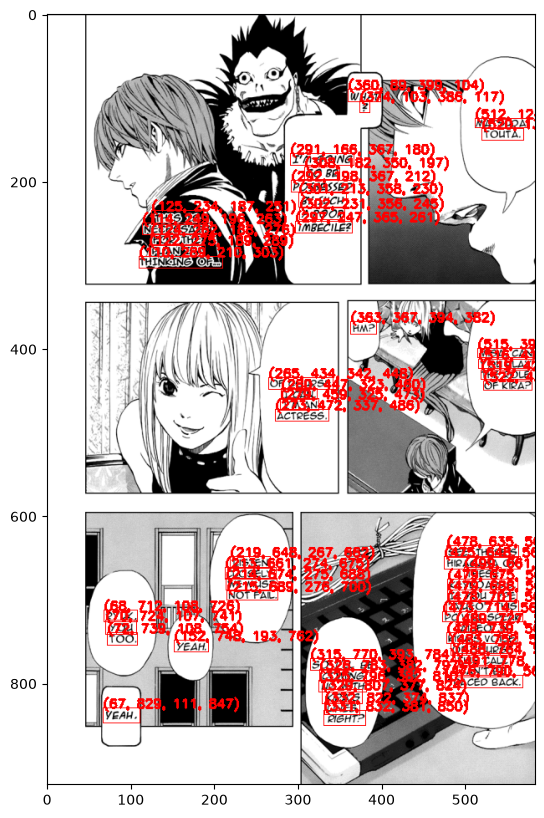

In [ ]:
draw_bounding_boxes(panel, bboxes, (0, 0, 255), False)
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
plt.show()


In [ ]:
#draw_bounding_boxes(panel, groupped_bboxes, (0, 0, 0), debug=False)
#plt.figure(figsize=(20, 10))
#plt.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
#plt.show()

In [ ]:
#def extract_ROI(image, detection):
#    ROI = []
#    for bbox in detection[0][0]:
#        ROI.append(panel[bbox[2] : bbox[3], bbox[0]: bbox[1]])
#    return ROI
#ROI = extract_ROI(panel, detection)
#
#i = 0
#for roi in ROI:
#    if i < 10:
#        plt.figure(figsize=(10, 5))
#        plt.imshow(roi)
#        plt.show()
#        i+=1

In [ ]:
def flip_ROI(image, detection, ROI):
    ROI = list(map(np.fliplr, ROI))
    for bbox, roi in zip(detection[0][0], ROI):
        panel[bbox[2] : bbox[3], bbox[0]: bbox[1]] = roi

flip_ROI(panel, detection, ROI)

NameError: name 'ROI' is not defined

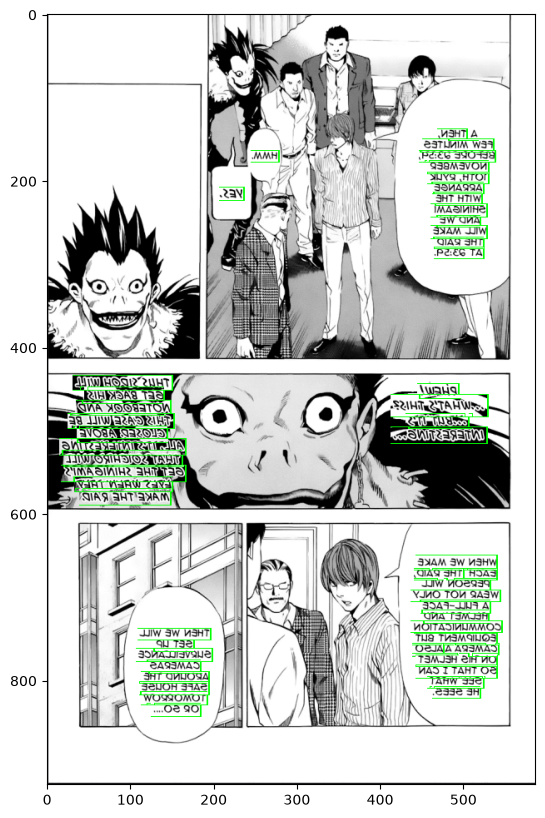

In [ ]:
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
plt.show()

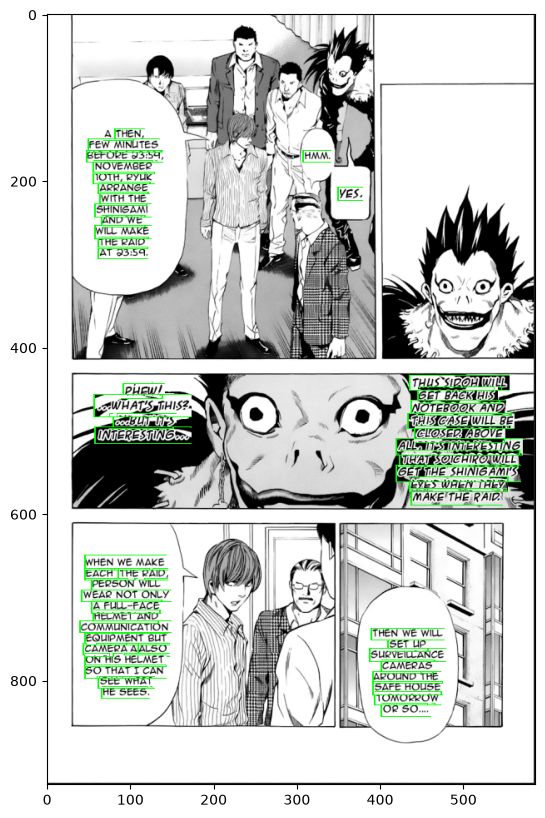

In [ ]:
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(np.fliplr(panel), cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
cv2.imshow(mat=cv2.cvtColor(np.fliplr(panel), cv2.COLOR_BGR2RGB), winname="J")
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.13.0) /io/opencv/modules/highgui/src/window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


In [ ]:
import fitz
import cv2
import numpy as np
import time

start = time.perf_counter()
def pdf_page_to_cv(input_path, output_path, dpi=200):
    with fitz.open(input_path) as doc:

            #First, extract the images from the PDF as a NumPy array and then store it in a list as a OpenCV object.
            i = 0
            for page in doc:
                start = time.perf_counter()
                pix = page.get_pixmap(dpi=dpi, alpha=False) 
                panel = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
                panel = cv2.cvtColor(panel, cv2.COLOR_RGB2BGR)
                cv2.imwrite(filename=f"{output_path}/page{i}.png", img=panel)
                print(f"page{i} done in {time.perf_counter() - start}s")
                i += 1

pdf_page_to_cv("testPDF.pdf", output_path="/home/vhvhs/MirrorMyManga/input")
print(f"Done in {time.perf_counter() - start}s")

page0 done in 3.3410858049974195s
page1 done in 3.0406546859994705s
page2 done in 3.2754486330013606s
page3 done in 3.3627831140001945s
page4 done in 3.3085483629984083s


KeyboardInterrupt: 

In [ ]:
from PIL import Image
# loading the image
img = Image.open("/home/vhvhs/MirrorMyManga/input/page2.png")

# fetching the dimensions
wid, hgt = img.size

# displaying the dimensions
print(str(wid) + "x" + str(hgt))

5523x8489


In [ ]:
from os import listdir

# get the path/directory
folder_dir = "Output"
for images in listdir(folder_dir):

    # check if the image ends with png
    if (images.endswith(".png")):
        print(images)

page0.png
page1.png
page2.png
page3.png
page4.png
page5.png
page6.png
page7.png
page8.png
page9.png
page10.png
page11.png
page12.png
page13.png
page14.png
page15.png
page16.png
page17.png
page18.png
page19.png
page20.png
page21.png
page22.png
page23.png
page24.png
page25.png
page26.png
page27.png
page28.png
page29.png
page30.png
page31.png
page32.png
page33.png
page34.png
page35.png
page36.png


In [ ]:
# Verify that PaddleOCR is installed successfully
import paddleocr
print(f"PaddleOCR version: {paddleocr.__version__}")

# If you use the local paddle_static inference engine, you can further verify PaddlePaddle and GPU availability
import paddle
print(f"Paddle version: {paddle.__version__}")
print(f"GPU available: {paddle.is_compiled_with_cuda()}")
print(f"GPU count: {paddle.device.cuda.device_count()}")

# If you use the transformers inference engine, you can further verify the transformers dependency
import transformers
print(f"Transformers version: {transformers.__version__}")

PaddleOCR version: 3.7.0
Paddle version: 3.3.0
GPU available: False
GPU count: 0
Transformers version: 5.12.1


In [ ]:
import os
import img2pdf
def save_img_as_pdf(input_path, output_path):
        img_name_list = []

        # convert all files ending in .jpg inside a directory
        imgs_name_list = []
        for fname in os.listdir(input_path):
            if fname.endswith(".png") or fname.endswith(".jpg") or fname.endswith(".jpeg"):
                img_path = os.path.join(input_path, fname)
                imgs_name_list.append(img_path)

        with open(output_path, "wb") as f:
            f.write(img2pdf.convert(imgs_name_list))

save_img_as_pdf(input_path="/home/vhvhs/MirrorMyManga/result", output_path="/home/vhvhs/MirrorMyManga/result.pdf")

/home/vhvhs/MirrorMyManga/.venv/lib64/python3.12/site-packages/PIL/Image.py:3574: DecompressionBombWarning: Image size (93761005 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


KeyboardInterrupt: 